# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name: Haley Benge
## Date: 3/2/2026
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [55]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [56]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [57]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [58]:

X = pd.get_dummies(X, columns=["odor","spore-print-color", "gill-size", "gill-color", "bruises"], prefix_sep=" = ")
X.head()


,odor = a,odor = c,odor = f,odor = l,odor = m,odor = n,odor = p,odor = s,odor = y,spore-print-color = b,...,gill-color = k,gill-color = n,gill-color = o,gill-color = p,gill-color = r,gill-color = u,gill-color = w,gill-color = y,bruises = f,bruises = t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [59]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


## 6️⃣ Train a small decision tree (Add Code)

In [60]:

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [61]:

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.959

Confusion Matrix:
 [[1052    0]
 [  83  896]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      1052
           1       1.00      0.92      0.96       979

    accuracy                           0.96      2031
   macro avg       0.96      0.96      0.96      2031
weighted avg       0.96      0.96      0.96      2031



## 8️⃣ Visualize the decision tree (Add Code)

In [62]:
df.value_counts("odor")

,count
odor,
n,3528
f,2160
s,576
y,576
a,400
l,400
p,256
c,192
m,36


In [63]:
df.value_counts("spore-print-color")

,count
spore-print-color,
w,2388
n,1968
k,1872
h,1632
r,72
b,48
o,48
u,48
y,48


In [64]:
df.value_counts("gill-size")

,count
gill-size,
b,5612
n,2512


In [65]:
df.value_counts("gill-color")

,count
gill-color,
b,1728
p,1492
w,1202
n,1048
g,752
h,732
u,492
k,408
e,96


In [66]:
df.value_counts("bruises")

,count
bruises,
f,4748
t,3376


## 9️⃣ Print IF–THEN rules (Add Code)

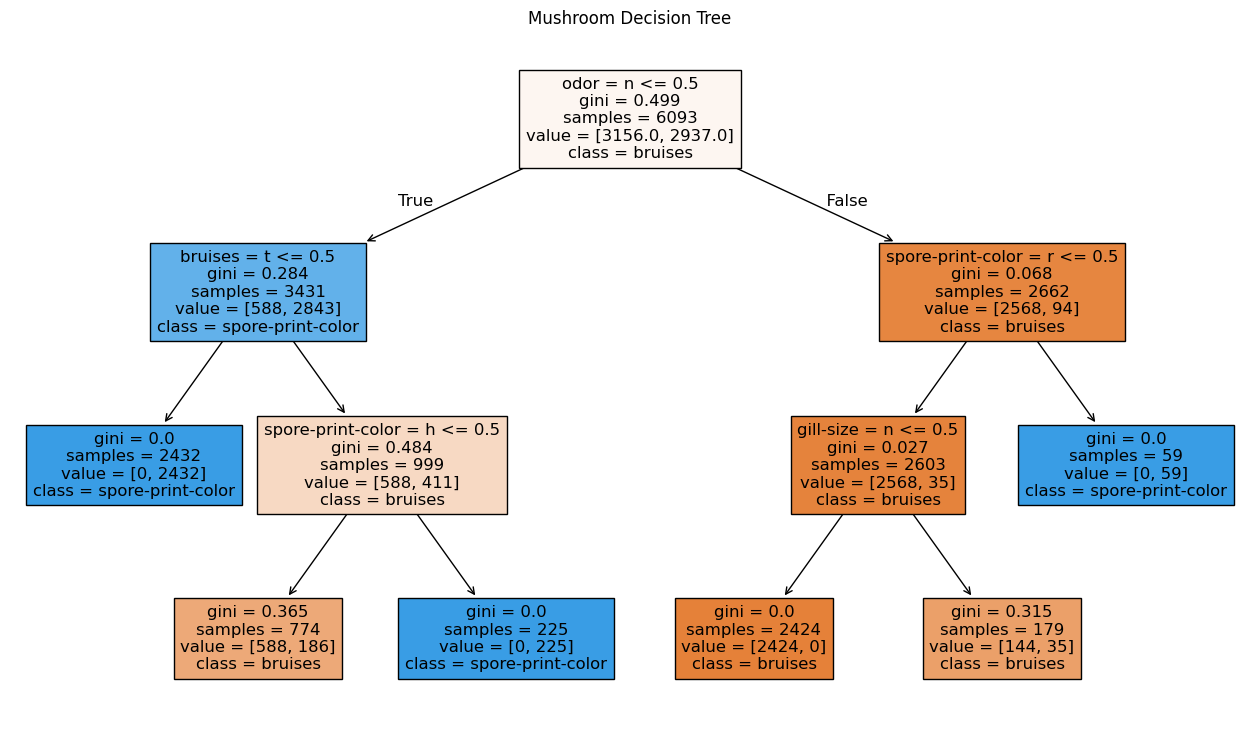

In [67]:
plt.figure(figsize=(16,9))
plot_tree(model, feature_names=X.columns, class_names=["bruises","spore-print-color"], filled=True)
plt.title("Mushroom Decision Tree")
plt. show()

In [68]:
#add the heatmap from the zybook

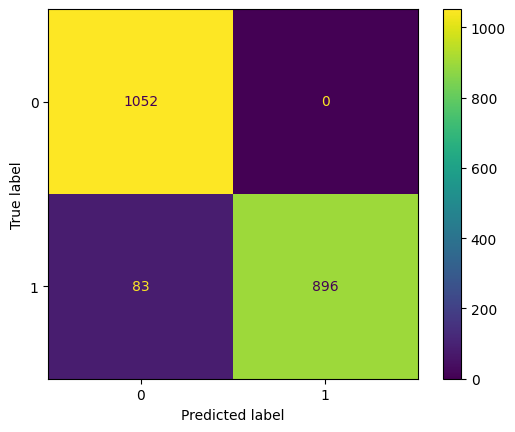

In [69]:
import sklearn.metrics as metrics
y_pred = model.predict(X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [70]:
metrics.accuracy_score(y_test, y_pred)

0.9591334318069916

In [71]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1052,    0],
       [  83,  896]])

---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy? <br>
The model accuracy score is .959, or roughly 96%.
2. How many poisonous mushrooms were correctly classified? <br>
896 poisonous mushrooms were correctly classified.
3. How many poisonous mushrooms were incorrectly predicted as edible? <br>
83 mushrooms were incorrectly predicted as edible.
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one? <br>
Misclassifying a poisonous mushroom is more important because this could lead to someone eating a poisonous mushroom and causing them harm, misclassifying an edible mushroom would not cause any one physical harm.

### Understanding the Tree
5. What feature appears at the **root node**? <br>
Odor is the root node.
6. What question is the root node asking in plain English? <br>
The root is asking if the mushroom has an oder value of less than or equal to 0.5, with mushroom with a value less than or equal 0.5 having an oder, and those with a value greater than 0.5 not having an odor.
7. Describe what the **left branch** and **right branch** mean. <br>
Left branch means the mushroom has no odor, and the right branch means that the mushroom does have an odor.
### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on? <br>
   The left nodes splits on mushrooms with bruises less than or equal to 0.5 and the right node splits on mushrroms with spore-print-color less than or equal to 0.5.
   - What question is each node asking? <br>
   The left node is asking if the bruise value is less than or equal to 0.5, meaning does the mushroom bruise or not. The right node is asking if the spore-print-color is less than or equal to 0.5 meaning does the mushroom have the print or not.
   - What does following the left vs right branch mean? <br>
   Following the left branch means the features value is less than or equal to 0.5, and following the right branch means the feature has a value greater than 0.5.

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English. <br>
If the mushroom has an odor, has spore print-print-color less than or equal to 0.5, and the gill size is less than or equal to 0.5 the mushroom is poisonous.
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous? <br>
Odor seems to be the most important feature because it is the rootnode.
### Exploration
11. Change `max_depth` to 2. What changed? <br>
The Tree became smaller and simplere with fewer splots. It only grows 2 levels deep so less features are used.
12. Change `max_depth` to 5. What changed? <br>
The tree becomes larger and more detailed. It grows more levels and more features are used.